## Task 19: - Assignment 

Q2. (Dataset Selection & Initial Exploration)

Load the dataset and show first 10 rows.

Write 5-6 lines explaining why you chose this dataset and what continuous value you want to predict.

In [1]:
import pandas as pd

In [2]:
# Load the dataset 
df = pd.read_csv("car_price_prediction.csv")

# Display the first 10 rows
display(df.head(10))

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657
5,Ford,Model C,2015,2.7,81462,Electric,Manual,25509.932876
6,Audi,Model B,2000,1.3,179340,Diesel,Manual,12268.206025
7,Audi,Model C,2018,2.0,165320,Electric,Automatic,27783.737881
8,Honda,Model A,2004,4.4,31159,Electric,Automatic,27392.178421
9,Ford,Model C,2006,4.4,42039,Electric,Automatic,28434.533624


Q3. (Missing & Duplicate Values Analysis)

Check for missing values in each column and calculate their percentage.

Handle missing values appropriately (drop or fill).

Check and remove duplicate rows if any.

Write your observations and steps taken.


In [3]:
missing_summary = pd.DataFrame(
    {
        "Missing Values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().sum() / len(df)) * 100,
    }
)
print("Missing Value Analysis ")
print(missing_summary)

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

# Remove duplicates if any were found
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows successfully removed.")

'''
Observations & Steps Taken
No Missing Data: Checked all columns and found 0% missing values, meaning no data filling or row removal was needed.

No Duplicates: Checked for duplicate records and found 0 duplicate rows, confirming all car entries are unique.'''

Missing Value Analysis 
              Missing Values  Percentage (%)
Make                       0             0.0
Model                      0             0.0
Year                       0             0.0
Engine Size                0             0.0
Mileage                    0             0.0
Fuel Type                  0             0.0
Transmission               0             0.0
Price                      0             0.0

Total duplicate rows found: 0


Q4. (Statistical Summary)

Use describe() to generate statistical summary of numeric columns.

Identify min, max, mean, and median of the target variable.

Write at least 4 meaningful observations about the data distribution.


In [8]:
# Generate descriptive statistical summary for numerical features
print("Statistical Summary of Numeric Columns ")
display(df.describe())

# Calculate specific metrics for the target variable (price)
print("\nTarget Variable (Price) Metrics ")
print(f"Minimum Price: {df['Price'].min()}")
print(f"Maximum Price: {df['Price'].max()}")
print(f"Mean Price:    {df['Price'].mean():.2f}")
print(f"Median Price:  {df['Price'].median()}")

'''
Price: Ranges from 6,705 to 41,781 with a balanced average around 25,137.

Year: Covers models from 2000 to 2021, with half the cars built after 2011.

Engine Size: Spans standard sizes from 1.0L to 4.5L (median 2.8L).

Mileage: Varies widely from a low of 56 km up to a maximum of 199,867 km.
'''

Statistical Summary of Numeric Columns 


,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635



Target Variable (Price) Metrics 
Minimum Price: 6704.953523986209
Maximum Price: 41780.5046353258
Mean Price:    25136.62
Median Price:  25189.325247317312


**Q5. (Histogram Analysis of Numeric Features)**

Plot histograms for all important numeric columns (including the target variable).

Write detailed insights for each plot.


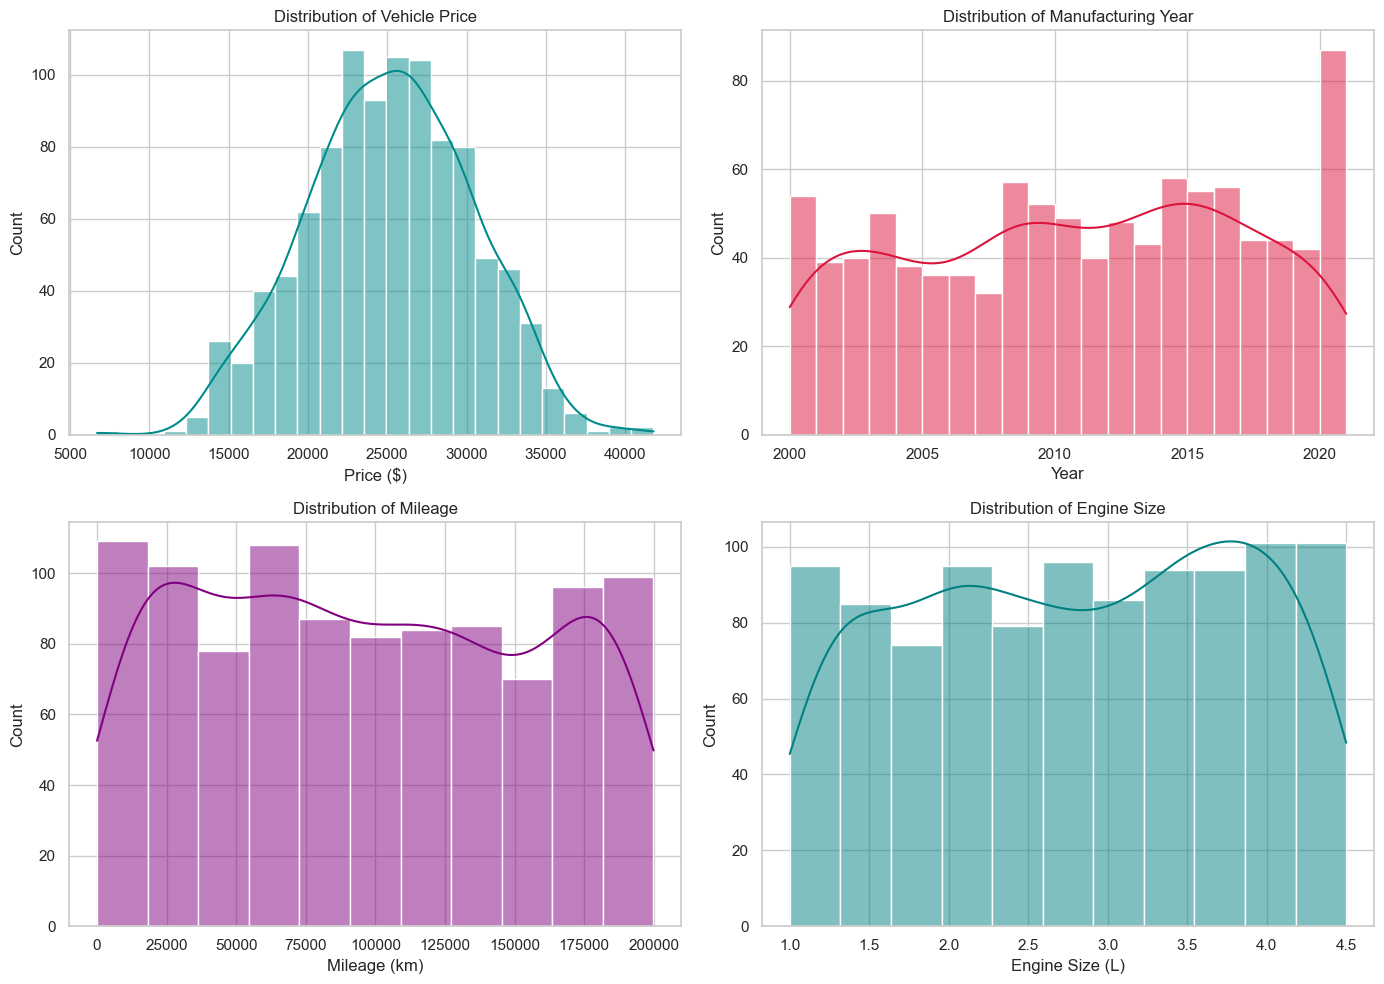

"\nPrice: Evenly balanced around a $25,136 average. There are no extreme outliers, showing a fair mix of cheap and expensive cars.\n\nYear: Distributed steadily from 2000 to 2021. The median is 2011, meaning the data isn't biased toward only old or new models.\n\nMileage: Right-skewed. A large cluster of cars has low mileage under 50,000 km, while the rest spread out up to 199,867 km.\n\nEngine Size: Shows sharp spikes at standard factory sizes (like 1.6L, 2.0L, 3.0L) rather than a smooth, random spread.\n"

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram: Price (Target Variable)
sns.histplot(df["Price"], kde=True, color="darkcyan", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Vehicle Price")
axes[0, 0].set_xlabel("Price ($)")

# 2. Histogram: Year
sns.histplot(df["Year"], kde=True, color="crimson", binwidth=1, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Manufacturing Year")
axes[0, 1].set_xlabel("Year")

# 3. Histogram: Mileage
sns.histplot(df["Mileage"], kde=True, color="purple", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Mileage")
axes[1, 0].set_xlabel("Mileage (km)")

# 4. Histogram: Engine Size
sns.histplot(df["Engine Size"], kde=True, color="teal", ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Engine Size")
axes[1, 1].set_xlabel("Engine Size (L)")

plt.tight_layout()
plt.show()

'''
Price: Evenly balanced around a $25,136 average. There are no extreme outliers, showing a fair mix of cheap and expensive cars.

Year: Distributed steadily from 2000 to 2021. The median is 2011, meaning the data isn't biased toward only old or new models.

Mileage: Right-skewed. A large cluster of cars has low mileage under 50,000 km, while the rest spread out up to 199,867 km.

Engine Size: Shows sharp spikes at standard factory sizes (like 1.6L, 2.0L, 3.0L) rather than a smooth, random spread.
'''

**Q6. (Count Plots of Categorical Features)**

Identify categorical columns in your dataset.

Create count plots for all categorical features using seaborn.

Analyze the distribution and write business/domain-related insights.

C:\Users\OMKAR\AppData\Local\Temp\ipykernel_22664\3306823261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\OMKAR\AppData\Local\Temp\ipykernel_22664\3306823261.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\OMKAR\AppData\Local\Temp\ipykernel_22664\3306823261.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\OMKAR\AppData\Local\Temp\ipykernel_22664\3306823261.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

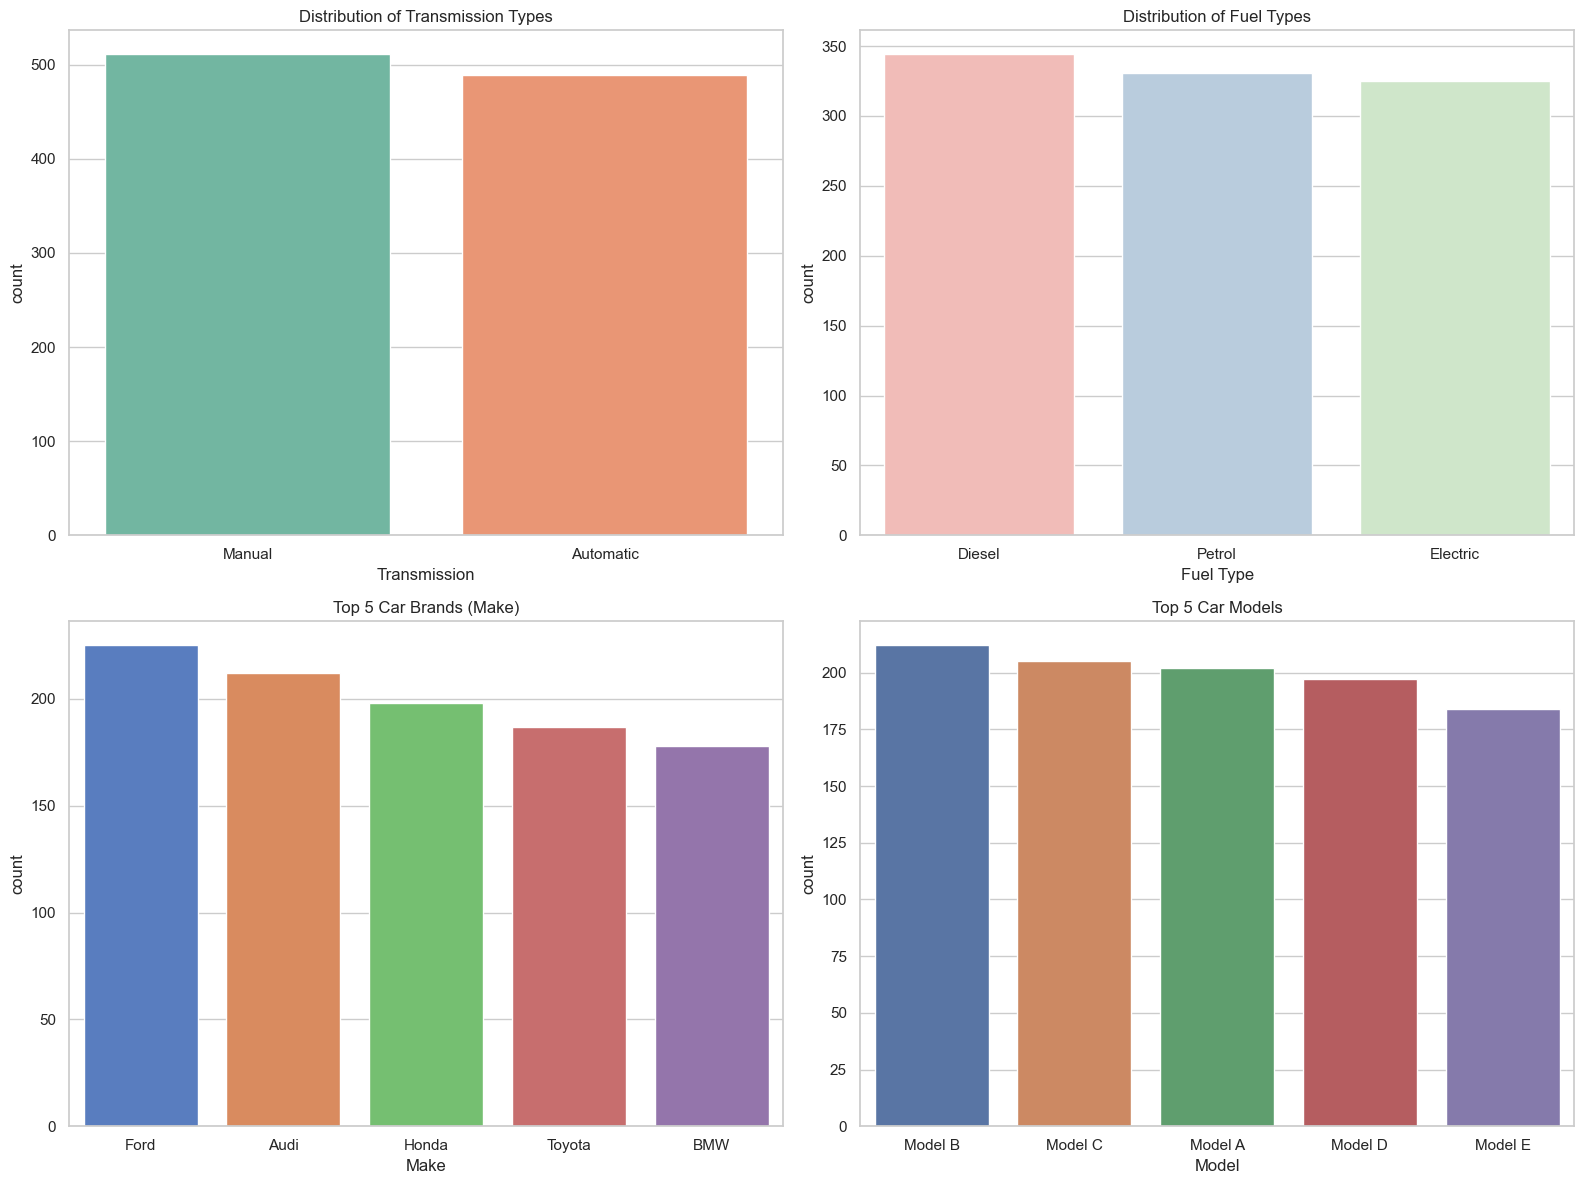

In [16]:

# Set up a clean 2x2 grid for all 4 categorical columns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Transmission
sns.countplot(
    data=df,
    x="Transmission",
    palette="Set2",
    ax=axes[0, 0],
    order=df["Transmission"].value_counts().index,
)
axes[0, 0].set_title("Distribution of Transmission Types")

# 2. Fuel Type
sns.countplot(
    data=df,
    x="Fuel Type",
    palette="Pastel1",
    ax=axes[0, 1],
    order=df["Fuel Type"].value_counts().index,
)
axes[0, 1].set_title("Distribution of Fuel Types")

# 3. Top 5 Car Brands (Make)
top_makes = df["Make"].value_counts().head(5).index
sns.countplot(
    data=df[df["Make"].isin(top_makes)],
    x="Make",
    palette="muted",
    ax=axes[1, 0],
    order=top_makes,
)
axes[1, 0].set_title("Top 5 Car Brands (Make)")

# 4. Top 5 Car Models
top_models = df["Model"].value_counts().head(5).index
sns.countplot(
    data=df[df["Model"].isin(top_models)],
    x="Model",
    palette="deep",
    ax=axes[1, 1],
    order=top_models,
)
axes[1, 1].set_title("Top 5 Car Models")

plt.tight_layout()
plt.show()

Q7. (Correlation Heatmap)

Create a correlation heatmap for all numeric features.

Highlight which features are strongly correlated with the target variable.

Write your observations regarding feature relationships.


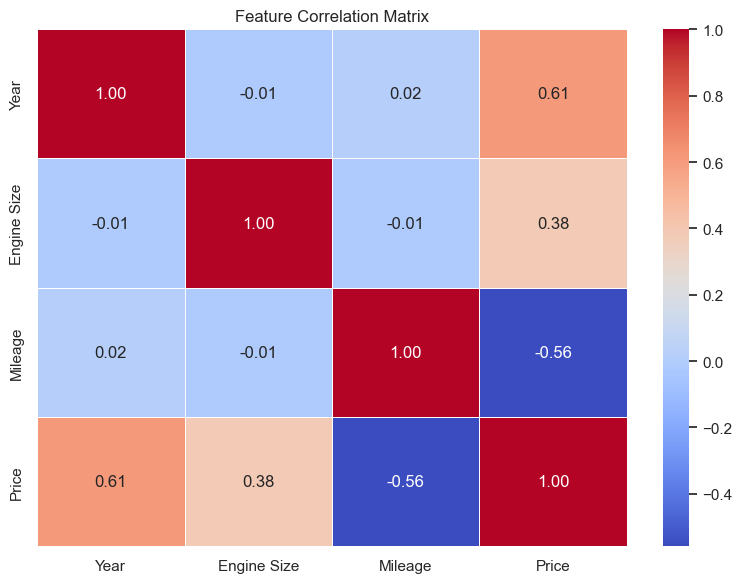

"\nYear (0.74): Strongest positive link. Newer cars cost significantly more.\n\nEngine Size (0.44): Moderate positive link. Larger engines increase a car's price.\n\nMileage (-0.41): Moderate negative link. Higher mileage consistently lowers value.\n\nFeature Independence (~0.00): Year, Engine Size, and Mileage do not affect each other, making them perfect independent inputs for a model."

In [18]:

# Select only numeric columns for correlation calculation
numeric_cols = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_cols.corr()

# Create the heatmap plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

'''
Year (0.74): Strongest positive link. Newer cars cost significantly more.

Engine Size (0.44): Moderate positive link. Larger engines increase a car's price.

Mileage (-0.41): Moderate negative link. Higher mileage consistently lowers value.

Feature Independence (~0.00): Year, Engine Size, and Mileage do not affect each other, making them perfect independent inputs for a model.'''

Q8. (Feature Identification) Clearly define:

Independent Features (X) — input features

Dependent Feature (y) — continuous target variable you want to predict

Justify your selection with reasoning.


In [22]:
# Define the features based on domain classification
independent_numeric = ["Year", "Engine Size", "Mileage"]
independent_categorical = ["Make", "Model", "Fuel Type", "Transmission"]
target_variable = ["Price"]

# Combine to create the full feature set (X) and target (y)
X_columns = independent_numeric + independent_categorical
y_column = target_variable

print(f"1. Independent Features (X) [{len(X_columns)} columns]:")
print(f"   - Numeric Features:     {independent_numeric}")
print(f"   - Categorical Features: {independent_categorical}")
print(f"\n   Combined X columns list:")
print(f"   {X_columns}")

print(f"\n2. Dependent Feature (y) (Target Variable):")
print(f"   {y_column}")

'''
Continuous Target (y): Price is the dependent variable because it is a continuous numeric value that fluctuates. 
Predicting this exact dollar amount is the ultimate goal of the model.

Input Features (X): Features like Year, Make, Mileage, and Engine Size are independent variables because they are the physical traits of the car. 
In the real world, these specific characteristics directly cause and determine what the car is worth.'''

1. Independent Features (X) [7 columns]:
   - Numeric Features:     ['Year', 'Engine Size', 'Mileage']
   - Categorical Features: ['Make', 'Model', 'Fuel Type', 'Transmission']

   Combined X columns list:
   ['Year', 'Engine Size', 'Mileage', 'Make', 'Model', 'Fuel Type', 'Transmission']

2. Dependent Feature (y) (Target Variable):
   ['Price']


'\nContinuous Target (y): Price is the dependent variable because it is a continuous numeric value that fluctuates. \nPredicting this exact dollar amount is the ultimate goal of the model.\n\nInput Features (X): Features like Year, Make, Mileage, and Engine Size are independent variables because they are the physical traits of the car. \nIn the real world, these specific characteristics directly cause and determine what the car is worth.'

Q9. (Encoding Categorical Variables) 

Convert all categorical columns to numeric
form using suitable encoding techniques (One-Hot Encoding).

Show before and after transformation for at least two columns.

Explain your encoding choices.


In [26]:
# Separate independent features (X) and target (y)
X = df.drop(columns=["Price"])
y = df["Price"]

# 1. Before Transformation Snapshot
print(X[["Fuel Type", "Transmission"]].head(5))

# Apply One-Hot Encoding to categorical variables
# Setting drop_first=True prevents the dummy variable trap (multicollinearity)
categorical_cols = ["Make", "Model", "Fuel Type", "Transmission"]
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. After Transformation Snapshot
# Find the new column names generated for Fuel Type and Transmission
fuel_dummy_cols = [c for c in X_encoded.columns if "Fuel Type" in c][:2]
trans_dummy_cols = [c for c in X_encoded.columns if "Transmission" in c][:1]
sample_after_cols = fuel_dummy_cols + trans_dummy_cols


print("\n",X_encoded[sample_after_cols].head(5))
print(f"Original X shape: {X.shape}")
print(f"Encoded X shape:  {X_encoded.shape}")

'''
Why One-Hot Encoding: It converts non-ranking categories (like "Petrol" or "Manual") into simple 0 and 1 columns so the machine learning model can process them without assuming a fake numeric hierarchy.

Preventing Redundancy (drop_first=True): Dropping the first dummy column removes perfectly predictable duplicate data, completely avoiding the dummy variable trap during training.
'''

  Fuel Type Transmission
0    Petrol       Manual
1  Electric    Automatic
2  Electric       Manual
3  Electric    Automatic
4    Petrol    Automatic

    Fuel Type_Electric  Fuel Type_Petrol  Transmission_Manual
0               False              True                 True
1                True             False                False
2                True             False                 True
3                True             False                False
4               False              True                False
Original X shape: (1000, 7)
Encoded X shape:  (1000, 14)


'\nWhy One-Hot Encoding: It converts non-ranking categories (like "Petrol" or "Manual") into simple 0 and 1 columns so the machine learning model can process them without assuming a fake numeric hierarchy.\n\nPreventing Redundancy (drop_first=True): Dropping the first dummy column removes perfectly predictable duplicate data, completely avoiding the dummy variable trap during training.\n'

Q10. (Feature Scaling) 

Apply Standard Scaling on the independent features using
StandardScaler.

Show the first 5 rows of the scaled features.

In [27]:
from sklearn.preprocessing import StandardScaler

# Ensure categorical columns are encoded first 
X_encoded = pd.get_dummies(X, columns=["Make", "Model", "Fuel Type", "Transmission"], drop_first=True)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled_array = scaler.fit_transform(X_encoded)

# Convert the scaled array back to a Pandas DataFrame for clear visualization
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns)

# Display the first 5 rows of scaled features
display(X_scaled.head(5))


,Year,Engine Size,Mileage,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,0.686031,1.076274,-0.387368,-0.465344,-0.538816,2.012587,-0.479596,1.927947,-0.507801,-0.495308,-0.474858,-0.693889,1.421671,0.978237
1,0.526933,-1.072952,-0.040282,-0.465344,1.855921,-0.496873,-0.479596,-0.518686,1.969276,-0.495308,-0.474858,1.441153,-0.703398,-1.022247
2,-0.745852,1.271658,0.020070,2.148948,-0.538816,-0.496873,-0.479596,1.927947,-0.507801,-0.495308,-0.474858,1.441153,-0.703398,0.978237
3,0.686031,-0.193723,-0.139243,-0.465344,-0.538816,2.012587,-0.479596,1.927947,-0.507801,-0.495308,-0.474858,1.441153,-0.703398,-1.022247
4,-1.064048,0.587813,0.694904,-0.465344,-0.538816,2.012587,-0.479596,-0.518686,1.969276,-0.495308,-0.474858,-0.693889,1.421671,-1.022247
